# Análisis Exploratorio de Datos: Titanic

En esta actividad usaremos la base de datos de pasajeros del Titanic para practicar **análisis exploratorio de datos (EDA)**.

El objetivo no es hacer la mayor cantidad posible de gráficos, sino aprender a **usar los datos para responder preguntas**.

## Pregunta de investigación

> **¿Qué características de los pasajeros estaban asociadas con la supervivencia en el Titanic?**


## Librerías de visualización
### Matplotlib

Matplotlib tiene dos métodos para crear una figura, uno directo y otro enfocado a objetos. 
Algunos links de interés:

- Argumentos que reciben matplotlib: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
- Más opciones de gráficos en https://matplotlib.org/2.0.2/gallery.html
- Para una lista de colores disponibles en Matplotlib, https://matplotlib.org/stable/gallery/color/named_colors.html
- Explicación de plt y ax https://towardsdatascience.com/what-are-the-plt-and-ax-in-matplotlib-exactly-d2cf4bf164a9


### Seaborn
Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos. A diferencia de Matplotlib, ésta no viene por defecto en Pandas. 
Galería de gráficos: https://seaborn.pydata.org/examples/index.html

Otro link útil para visualizaciones en Python: https://python-graph-gallery.com/


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("white")


## Carga de los datos

Cada fila de la base de datos corresponde a **un pasajero**.

Las principales características disponibles son:

- `Survived`: supervivencia, 0 = no, 1 = sí
- `Pclass`: clase del pasajero, 1 = primera, 2 = segunda, 3 = tercera
- `Sex`: sexo
- `Age`: edad
- `SibSp`: número de hermanos/as o cónyuges a bordo
- `Parch`: número de padres o hijos a bordo
- `Ticket`: identificador del pasaje
- `Fare`: tarifa pagada
- `Cabin`: cabina
- `Embarked`: puerto de embarque, C = Cherbourg, Q = Queenstown, S = Southampton


In [2]:
titanic = pd.read_csv("titanic_semana_02.csv")
titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### **cuáles variables son numéricas y cuáles son categóricas?**



**Categóricas:** Survived, Pclass, Sex, Embarked.
**Numéricas:** Age, SibSp, Parch, Fare.

# Parte 1: Comprender la muestra

## ¿Quiénes eran los pasajeros del Titanic?

Antes de estudiar la supervivencia, necesitamos comprender a quiénes representan los datos.

Preguntas iniciales:

- ¿Cuántos pasajeros hay?
- ¿Qué características contiene la base de datos?
- ¿Cómo se distribuyen por sexo y clase?
- ¿Qué edades aparecen?
- ¿Cuánto pagaron por sus pasajes?
- ¿Viajaban solos o acompañados?
- ¿Desde qué puerto embarcaron?

Revise la estructura general de la tabla: dimensión, columnas, estadística básica, etc.

### Ejemplo de gráfico: pasajeros por sexo

Para una característica categórica podemos comenzar contando cuántos pasajeros pertenecen a cada grupo.


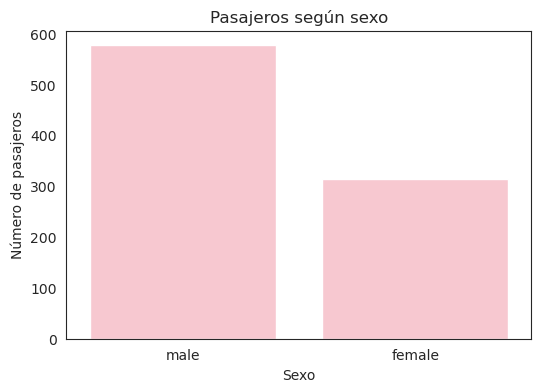

In [3]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Sex", color="pink")

plt.xlabel("Sexo")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según sexo")

plt.show()


### Ahora usted

**1. Grafique la cantidad de pasajeros según `Pclass`.**

- Qué clase contiene más pasajeros?
- La muestra está balanceada entre las tres clases?


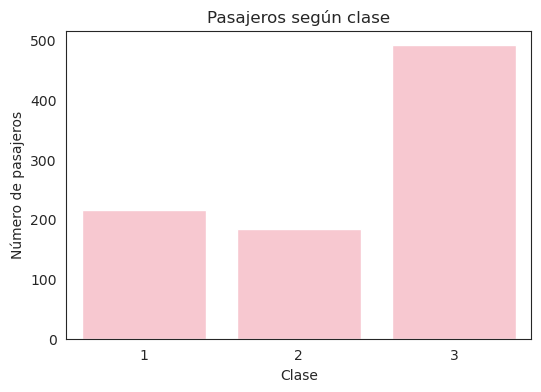

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(data=titanic, x="Pclass", color="pink")

plt.xlabel("Clase")
plt.ylabel("Número de pasajeros")
plt.title("Pasajeros según clase")

plt.show()

la clase 3 tiene la mayor cantidad de pasajeros (rondando los 500 pasajeros), seguida de la clase 1 (rondando los 200 pasajeros) y la clase 2 (poco mas de 180 pasajeros). La muestra no está balanceada, ya que alrededor del 55% de los pasajeros era Pclass3.

**2. Explore la distribución de `Age` con un histograma.**

Pruebe, por ejemplo, con 15, 30 y 50 bins.

- ¿Qué edades son más frecuentes?
- ¿La distribución parece simétrica?
- ¿El número de bins cambia su interpretación?


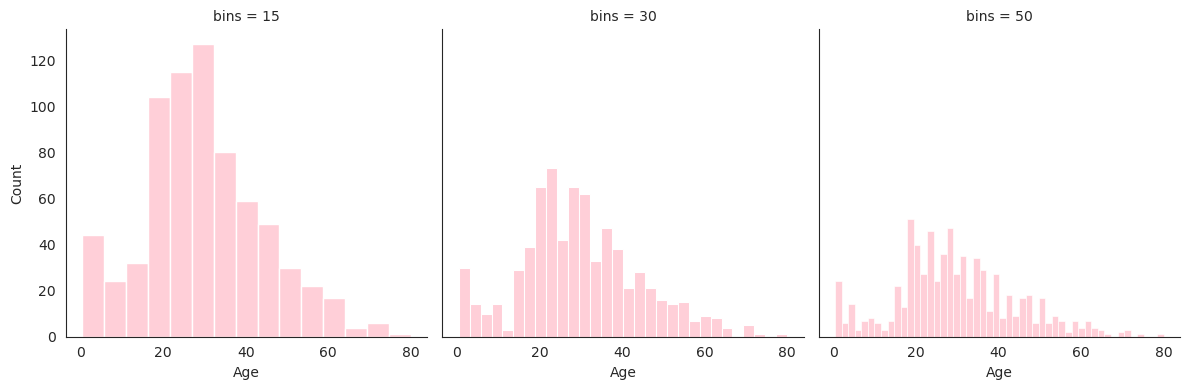

In [5]:

bins_df = pd.DataFrame({"bins_val": [15, 30, 50]})

titanic_expanded = pd.merge(titanic, bins_df, how="cross")

def hist_con_bins(data, **kwargs):
    b = int(data["bins_val"].iloc[0])
    sns.histplot(data=data, x="Age", color="pink", stat="count", bins=b)

g = sns.FacetGrid(titanic_expanded, col="bins_val", height=4)
g.map_dataframe(hist_con_bins)
g.set_titles("bins = {col_name}")

La edad más frecuente está entre 20 y 30 años . La distribución tiende a disminuir hacia edades mayores y muestra un pico adicional en niños pequeños. Con 15 bins se ve una forma más suave y con muchos 50 bins aparecen picos y valles, los cuales podrian estar interpretando datos que no son relevantes en nuestra muestra. el grafico con menos bins nos muestra la tendencia general de la muestra, mientras que a mayor bins se pueden observar tendencias locales.

<Axes: xlabel='Age', ylabel='Count'>

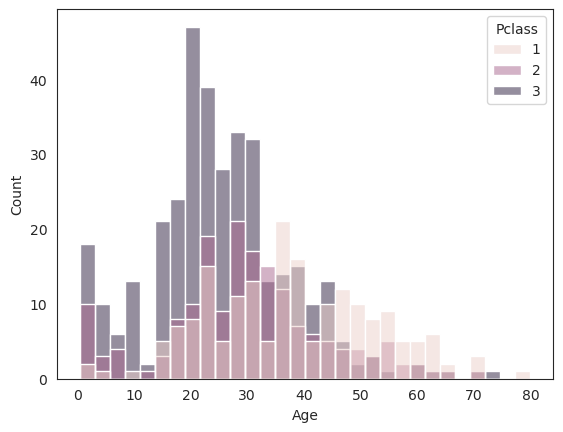

In [6]:

sns.histplot(data=titanic,
    x="Age", bins=30, hue="Pclass", stat="count")

**3. Explore la distribución de `Fare`.**

Puede usar un histograma o un boxplot.

- ¿La distribución es simétrica?
- ¿Existen tarifas muy superiores al resto?
- ¿Qué podría significar esto?


Media de Fare: 32.204207968574636
Mediana de Fare: 14.4542


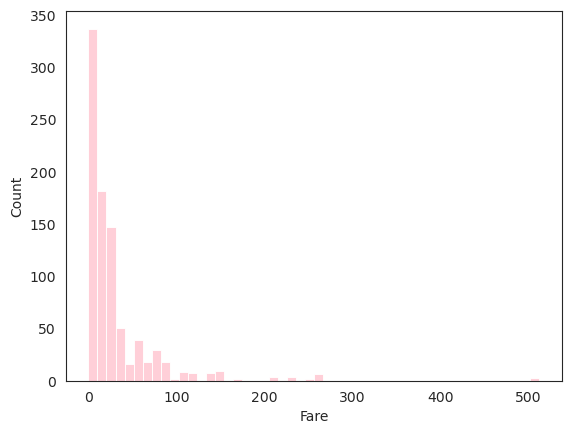

In [8]:
sns.histplot(data=titanic, x="Fare", bins=50, color="pink")
print("Media de Fare:", titanic["Fare"].mean())
print("Mediana de Fare:", titanic["Fare"].median()) #sacamos media y mediana para poder comparar y analizar outliers

la distribución es asimétrica hacia la derecha (media 32.2 vs mediana 14.5). Hay una tarifa que se puede considerar como un outliar debido a su gran diferencia con el resto de la muestra. Esto probablemente corresponde a un pequeño grupo de pasajeros de primera clase (oficiales de alto rango miembros de la aristocrasia inglesa).

# Parte 2: Calidad de los datos

## ¿Qué información falta y por qué podría importar?

Antes de interpretar cualquier patrón debemos revisar la calidad de los datos.

Nos interesa detectar:

- valores faltantes
- características con mucha información incompleta
- valores extremos o sospechosos
- decisiones de limpieza que puedan cambiar nuestras conclusiones


In [9]:
datos_faltantes = titanic.isnull().sum()
datos_faltantes


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Ejemplo de gráfico: valores faltantes

Podemos visualizar cuántos datos faltan en cada característica.


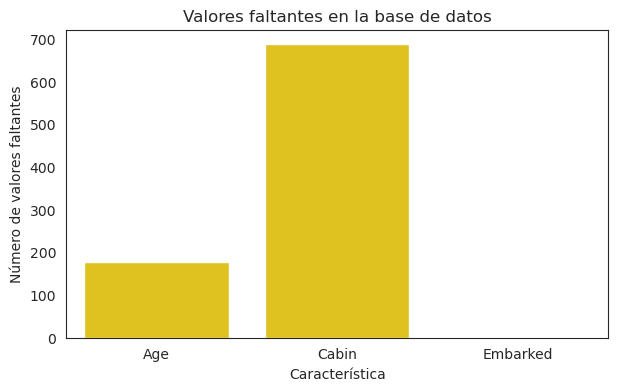

In [10]:
faltantes = datos_faltantes[datos_faltantes > 0]

plt.figure(figsize=(7,4))

sns.barplot(x=faltantes.index, y=faltantes.values, color='gold')

plt.xlabel("Característica")
plt.ylabel("Número de valores faltantes")
plt.title("Valores faltantes en la base de datos")

plt.show()


### Ahora usted

Observe especialmente `Age`, `Cabin` y `Embarked`.

**1. Compare la media y la mediana de `Age`.**

- Son similares?
- Es la media una buena representación de una edad típica?


In [11]:
print("Mean age:", titanic["Age"].mean())
print("Median age:", titanic["Age"].median())

Mean age: 29.69911764705882
Median age: 28.0


Son bastante similares, por lo que se podria considerar que la media es una variable representativa de la dad de la muestra , pero debemos recordar que siempre deemos considerar con mayor peso/relevancia a la mediana, debido a que se trata de una variable mas robusta.

**2. La edad tiene datos faltantes.**

- Le parece razonable reemplazar todas las edades faltantes por la media?
- Qué problema podría producir esa decisión en la distribución de edades?
- Qué otra estrategia consideraría?


No sería lo mejor en mi opinión, esto debido a que al reemplazar todos los faltantes por un único valor afectaría la variabilidad real y crea un pico artificial exactamente en la media, distorsionando la distribución real de las edades.Lo que haría, en cambio, sería usar la mediana (más robusta y menor variabilidad a outliers)

**3. `Cabin` tiene una gran cantidad de valores faltantes.**

- Intentaría rellenarlos?
- Eliminaría la característica?
- Podría el hecho de conocer o no la cabina contener información por sí mismo?

No hay una única respuesta correcta: justifique su decisión.


Con 687 de 891 valores faltantes, rellenar la variable no es confiable. Sin embargo, el solo hecho de tener o no tener registrada la cabina podría ser informativo por sí mismo (posiblemente correlacionado con la clase o con haber sobrevivido). Una opción razonable es crear una variable binaria de "tiene cabina registrada" en vez de eliminar la columna completa.

**4. `Embarked` tiene pocos datos faltantes.**

- Qué estrategia simple usaría en este caso?
- Por qué el tratamiento puede ser distinto al de `Cabin`?


Solo tenemos 2 valores faltantes, por lo que se podría rellenar con el puerto más común o eliminar los dos elementos de la muestra. El tratamiento es distinto al de Cabin porque aquí la proporción de datos faltantes es insignificante, a diferencia de la categoría de Cabin.

# Parte 3: Explorar relaciones entre características

## ¿Cómo se relacionan las características de los pasajeros?

Después de estudiar las características individualmente, podemos comenzar a buscar estructura en los datos.

Preguntas posibles:

- La tarifa pagada está relacionada con la clase?
- Las edades son similares en todas las clases?
- Quiénes viajaban acompañados?
- Hay características que contienen información parcialmente similar?



### Ejemplo de gráfico: tarifa según clase

Un boxplot permite comparar la distribución de una característica numérica entre distintos grupos.


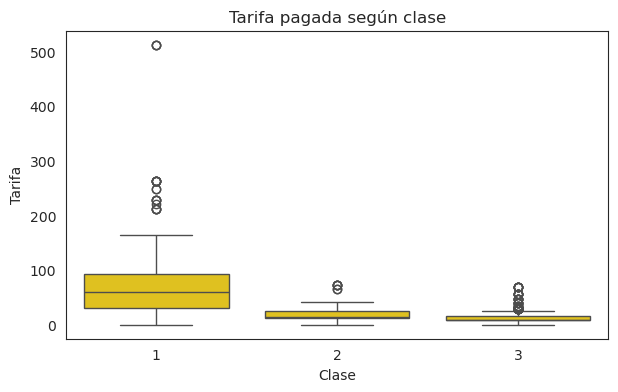

In [12]:
plt.figure(figsize=(7,4))

sns.boxplot(data=titanic, x="Pclass", y="Fare", color='gold')

plt.xlabel("Clase")
plt.ylabel("Tarifa")
plt.title("Tarifa pagada según clase")

plt.show()


### Preguntas

- La tarifa parece estar relacionada con la clase?
- Hay dispersión dentro de cada clase?
- Existen valores extremos?
- Diría que `Fare` y `Pclass` contienen exactamente la misma información?


### Ahora usted

**1. Compare la distribución de edad entre las tres clases.**

Use un gráfico que permita comparar las distribuciones.

- Los pasajeros tienen edades similares en todas las clases?
- Qué diferencias observa?


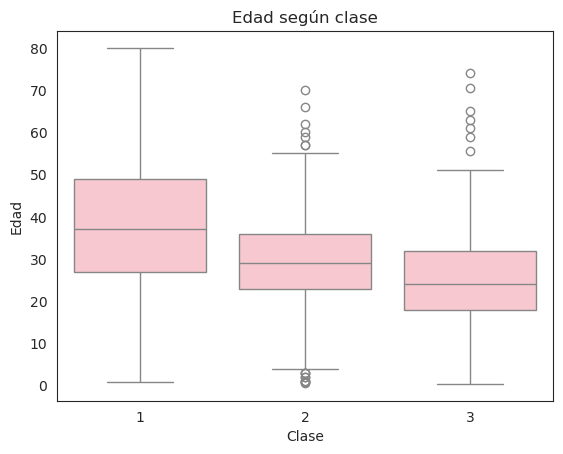

In [13]:
sns.boxplot(data=titanic, x="Pclass", y="Age", color="pink")

plt.xlabel("Clase")
plt.ylabel("Edad")
plt.title("Edad según clase")

plt.show()

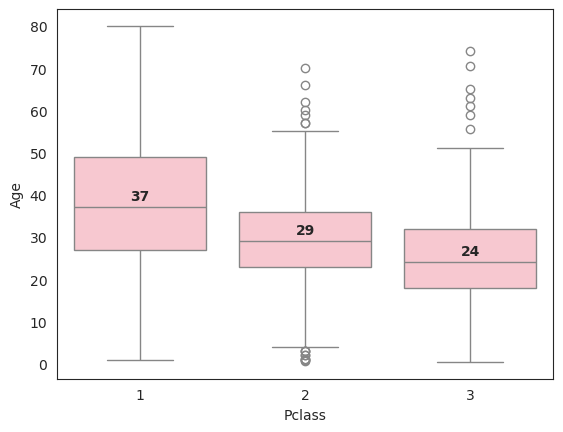

In [14]:
ax = sns.boxplot(data=titanic, x="Pclass", y="Age", color="pink")

medianas = titanic.groupby("Pclass")["Age"].median() #calculamos cdad mediana de cada boxplot usando pandas
for i, clase in enumerate(medianas.index):
    ax.text(i, medianas[clase] + 1, f"{medianas[clase]:.0f}", #me ayude de la IA para poder centrar la edad obtenida sobre cada boxplot del gráfico "ha=center"
            ha="center", va="bottom", fontweight="bold")

Los pasajeros de primera clase eran, en promedio, considerablemente mayores.

**2. Las características `SibSp` y `Parch` contienen información sobre familiares a bordo.**

Construya una nueva característica llamada `Familia`, que represente el número total de personas del grupo familiar incluyendo al propio pasajero:

\[
Familia = SibSp + Parch + 1
\]


In [15]:
titanic["Familia"] = titanic["SibSp"] + titanic["Parch"] + 1

**3. Explore la nueva característica `Familia`.**

- La mayoría de los pasajeros viajaba sola o acompañada?
- Hay grupos familiares muy grandes?
- Cambiaría su interpretación si solo mirara `SibSp` o `Parch` por separado?


<Axes: xlabel='Familia', ylabel='count'>

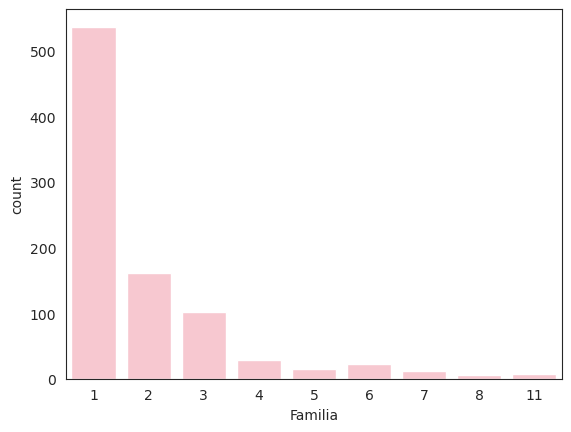

In [16]:
sns.countplot(data=titanic, x="Familia", color="pink")

La mayoría de los pasajeros viajaba sola (más de 500 pasajeros) y existe una minoría de personas que viaja con grupos familiares numerorsos. El hecho de combinar estas dos categorías nos revela información adicional a la que veríamos con solo mirar la tabla de datos. Alguien con SibSp=0 y Parch=0 viaja solo, pero alguien con SibSp=0, Parch=3 (viaja con hijos), pero si observaramos unicamente SibSp pensaríamos lo contrario.

# Parte 4: Investigar la supervivencia

## ¿Qué características estaban asociadas con la supervivencia?

Ahora incorporaremos `Survived`, la variable que queremos comprender.

Investigaremos si la supervivencia está asociada con características como:

- sexo
- clase
- edad
- tamaño del grupo familiar


### Ejemplo de gráfico: supervivencia según sexo

Como `Survived` toma valores 0 y 1, su promedio dentro de un grupo corresponde a la **fracción de pasajeros que sobrevivió**.

`seaborn.barplot` calcula por defecto la media de la variable del eje vertical.


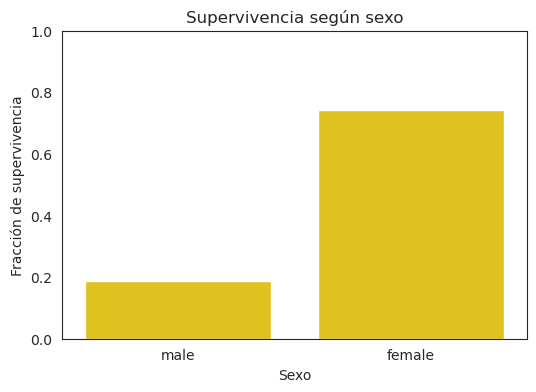

In [17]:
plt.figure(figsize=(6,4))

sns.barplot(data=titanic, x="Sex", y="Survived", errorbar=None, color='gold')

plt.xlabel("Sexo")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según sexo")
plt.ylim(0,1)

plt.show()


### Preguntas

- La fracción de supervivencia es similar para hombres y mujeres?
- Podemos concluir a partir de este gráfico por qué existe la diferencia?


No es similar en absoluto, existe una mayor proporcion de mujeres que sobrevivieron a comparación de los hombres, aunque a partir del gráfico no podemos deducir la razón podemos basarnos en roles de género determinados por comportamientos sociales conocidos.

### Ahora usted

**1. Explore la supervivencia según `Pclass`.**

- Hay diferencias entre las tres clases?
- Existe una tendencia?


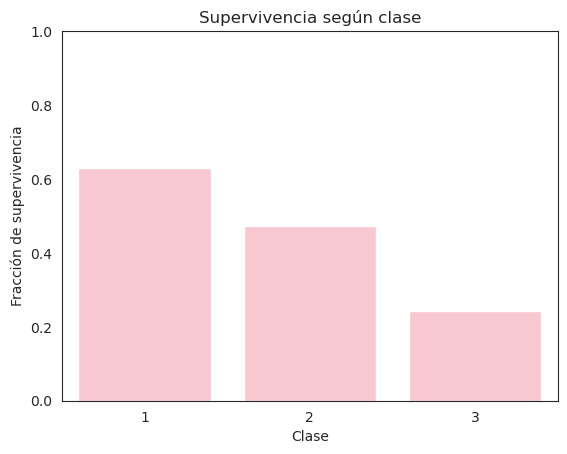

In [18]:
sns.barplot(data=titanic, x="Pclass", y="Survived", errorbar=None, color="pink")

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase")
plt.ylim(0,1)

plt.show()

hay una tendencia clara. A mejor clase, mayor probabilidad de supervivencia.

**2. Explore la supervivencia según edad.**

Puede comparar las distribuciones de edad de quienes sobrevivieron y quienes no sobrevivieron.

- La edad parece estar asociada con supervivencia?
- Hay algún grupo de edad que llame particularmente su atención?


Text(0.5, 1.0, 'Supervivencia según edad')

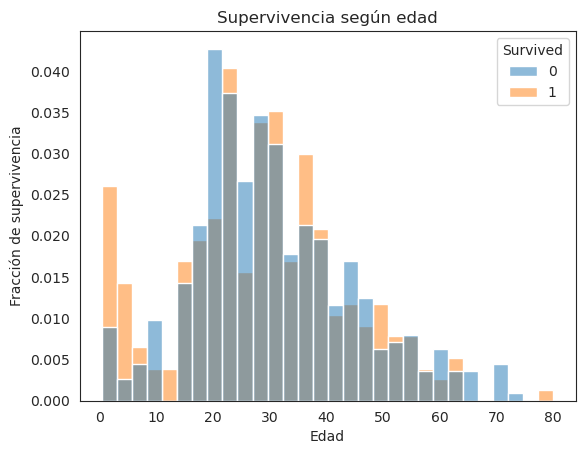

In [19]:
sns.histplot(data=titanic, x="Age", hue="Survived", stat="density", common_norm=False, bins=30)

plt.xlabel("Edad")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según edad")


**3. Explore la supervivencia según `Familia`.**

- Viajar solo parece favorable o desfavorable?
- La relación parece simple?
- Qué ocurre con los grupos familiares grandes?


<Axes: xlabel='Familia', ylabel='Survived'>

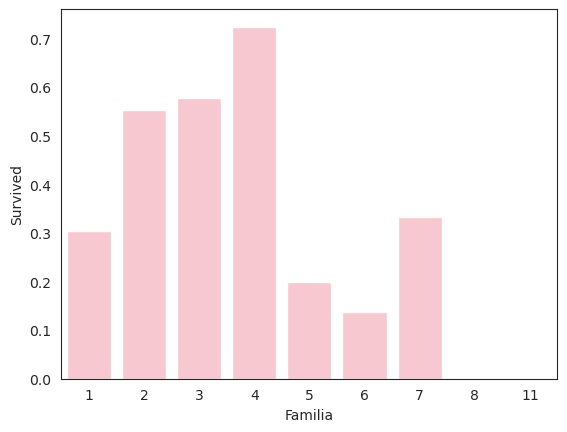

In [20]:
sns.barplot(data=titanic, x="Familia", y="Survived", errorbar=None, color="pink")


La supervivencia según familia ni sigue una tenencia lineal clara, aunque las familias pequeñas muestran una tasa de supervivencia superior al resto.

# Parte 5: Agregar contexto

## ¿Cambia una relación cuando consideramos otra característica?

Una relación global puede esconder comportamientos diferentes dentro de la muestra.

Ya estudiamos por separado:

- `Pclass` y supervivencia
- `Sex` y supervivencia

Ahora podemos preguntar:
 **¿La relación entre clase y supervivencia es igual para hombres y mujeres?**

Esta es una forma sencilla de análisis multivariado: consideramos varias características al mismo tiempo.


### Ejemplo de gráfico: clase, sexo y supervivencia


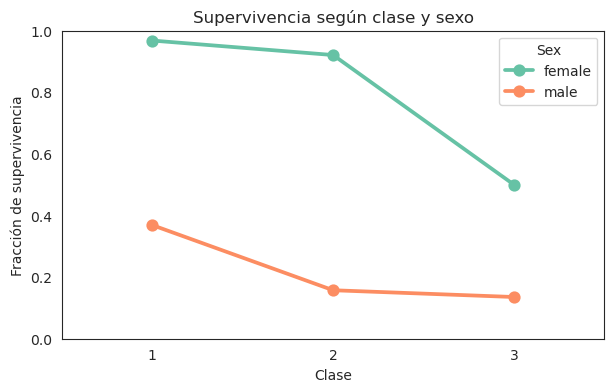

In [21]:
plt.figure(figsize=(7,4))

sns.pointplot(data=titanic,
              x="Pclass",
              y="Survived",
              hue="Sex",
              palette="Set2",
              errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según clase y sexo")
plt.ylim(0,1)

plt.show()


### Preguntas sobre el ejemplo

- La relación entre clase y supervivencia es igual para hombres y mujeres?
- Qué información se perdía cuando mirábamos solamente `Pclass`?
- Qué información se perdía cuando mirábamos solamente `Sex`?
- Hay algún grupo particularmente favorecido o desfavorecido?



### Ahora usted

**1. Cree una característica `Persona` con tres categorías:**

- `mujer`
- `hombre`
- `niño/a`

Considere como niño/a a un pasajero menor de 16 años.


In [29]:
# Complete el código

#titanic["Persona"] = #

# Revise el resultado
#titanic["Persona"].value_counts()#

def clasificar_persona(fila):             #creamos una funcion para definir la familia y poder clasificar entre edades y sexo al mismo tiempo
    if fila["Age"] < 16:
        return "niño/a"                 #otra idea seria utilizar un bucle tipo for y generar una lista a la que se le agreguen datos dependiendo del sexo y edad
    elif fila["Sex"] == "male":
        return "hombre"
    else:
        return "mujer"

titanic["Persona"] = titanic.apply(clasificar_persona, axis=1)

# Revise el resultado
titanic["Persona"].value_counts()


Persona
hombre    537
mujer     271
niño/a     83
Name: count, dtype: int64

**2. Explore la supervivencia según `Persona` y `Pclass`.**

- Los niños presentan el mismo patrón que los adultos?
- La clase sigue siendo importante dentro de cada grupo?
- Qué combinación de características parece asociarse con la mayor supervivencia?


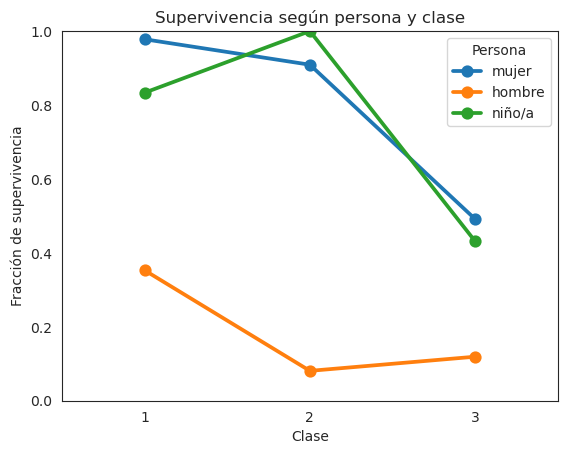

In [30]:
sns.pointplot(data=titanic, x="Pclass", y="Survived", hue="Persona", errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según persona y clase")
plt.ylim(0,1)

plt.show()

los niños no siguen exactamente el mismo patrón que los adultos. En segunda clase, el 100% de los niños sobrevivió, mucho más alto que los hombres adultos de esa misma clase. La clase sigue siendo muy relevante dentro de cada grupo. La combinación más favorecida es mujer de primera o segunda clase, mientras que la más desfavorecida es hombre de segunda o tercera clase. Tambien existe una tendencia entre que siguen los datos correspondientes a niños y mujeres a lo largo de todas las clases (tienden a mantenerse en posiciones similares).

**3. Elija una relación adicional para explorar incorporando una tercera característica.**

Algunas ideas:

- edad + sexo + supervivencia;
- tamaño de familia + clase + supervivencia;
- puerto de embarque + clase + supervivencia.

No necesita crear una figura complicada. El objetivo es responder una pregunta concreta.

**Escriba primero la pregunta que quiere investigar y luego construya el gráfico.**


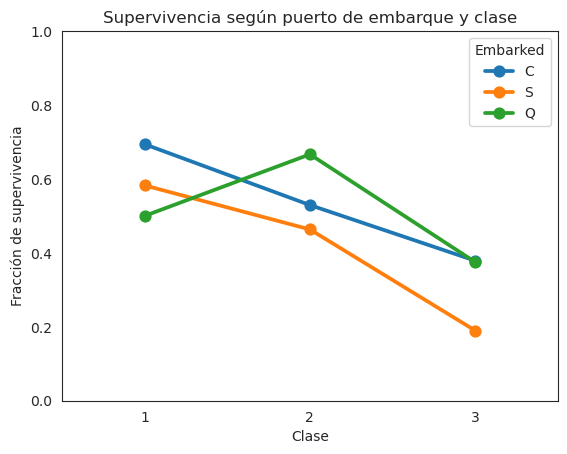

In [31]:


# Pregunta: ¿La relación entre puerto de embarque y supervivencia depende de la clase?

sns.pointplot(data=titanic, x="Pclass", y="Survived", hue="Embarked", errorbar=None)

plt.xlabel("Clase")
plt.ylabel("Fracción de supervivencia")
plt.title("Supervivencia según puerto de embarque y clase")
plt.ylim(0,1)

plt.show()

en primera clase, quienes embarcaron en Cherbourg (C) tuvieron mayor supervivencia en comparación a los que embarcaron en Southampton. Pero la mayoría de los pasajeros de tercera clase embarcó en Southampton (donde la tasa de supervivencia en 3ª clase es la más baja, así que el "efecto del puerto" de forma global nos dice que distintos puertos tenían distinta composición de clases, no un efecto directo del puerto en sí. (tal vez también podría deberse a la disponibilidad de barcos salvavidas en cada sector de embarque)

# Parte 6: Conclusión

## ¿Qué podemos concluir?

El EDA no termina cuando encontramos diferencias entre grupos.

Queremos distinguir entre:

### Observación
Algo que vemos directamente en los datos.

### Interpretación
Cómo describimos ese patrón.

### Hipótesis
Una explicación posible que debería ser evaluada con más información.

Por ejemplo:

> **Observación:** las mujeres presentan una mayor fracción de supervivencia que los hombres.

- **Podemos concluir, solo a partir de esta base de datos, que durante la evacuación se dio prioridad a mujeres y niños?**
- **Qué información adicional necesitaríamos para evaluar esa hipótesis?**
- **Qué otras explicaciones podrían producir el mismo patrón de supervivencia?**

## Síntesis del análisis

Revise todas las figuras construidas y responda:

### 1. Quiénes eran los pasajeros del Titanic?

La muestra tiene 891 pasajeros. En donde, la mayoría eran hombres (577), y más de la mitad viajaba en tercera clase. La edad mas predominante ronda los 28-30 años. La mayoría viajaba sin familiares a bordo.


### 2. Qué características estaban asociadas con la supervivencia?

El sexo fue el factor más determinante (las mujeres sobrevivieron mucho más que los hombres), seguido de la clase (a mejor clase, mayor supervivencia) y la edad (los niños tuvieron "ventaja"). Viajar en un grupo familiar pequeño (2-4 personas) fue más favorable que viajar solo o en grupos muy grandes.



### 3. Qué relaciones cambiaron al considerar varias características al mismo tiempo?

Al combinar Pclass con Persona, vimos que el patrón de "mujeres y niños primero" no aseguraba una mayor supervivencia, si no que estaba sujeto a la clase. Por ejemplo, los niños de segunda clase sobrevivieron casi siempre (100%), pero esto no se cumple igual en tercera clase. Mirar solo Sex o solo Pclass por separado escondía esta interacción.

### 4. Encontró características que contienen información relacionada?

Fare y Pclass están fuertemente relacionadas (mayor tarifa en clases más altas), aunque no son idénticas. Existe una variabilidad de tarifas dentro de cada clase. También SibSp y Parch se combinan (En Familia se resume el tamaño del grupo que cualquiera de las dos separadas).

### 5. Qué resultado le pareció más inesperado?

Que las familias muy grandes tuvieran tasas de supervivencia muy bajas, incluso más bajas que viajar solo. Las familias con 5 o más integrantes tuvieron tasas de supervivencia menores del 30%. Hipótesis: podría ser más difícil manejar la evacuación de una familia numerosa, o estos grupos eran en su mayoria de tercera clase, donde el acceso a los botes salvavidas era menor.

# Conclusión final

## ¿Cuál es el perfil del pasajero típico que sobrevivió?

A partir de **sus propios resultados**, escriba una conclusión breve que caracterice al pasajero con mayor probabilidad de haber sobrevivido en esta muestra.

Considere, cuando corresponda:

- sexo
- edad
- clase
- tamaño del grupo familiar
- otras características que hayan resultado relevantes

Su respuesta debe estar respaldada por las figuras que construyó.


### Escriba aquí su conclusión

**El pasajero típico que sobrevivió...**

*(Complete con un párrafo breve basado en su análisis.)*


El pasajero típico que sobrevivió era una mujer de primera o segunda clase, tal vez acompañada de un grupo familiar pequeño. Las mujeres de primera o segunda clase alcanzaron tasas de supervivencia más altas. Los niños también tuvieron ventaja, especialmente en clases altas. Al contrario, el perfil con menor probabilidad de supervivencia fue un hombre adulto de tercera clase viajando solo, grupo que representa una gran parte de la muestra